# Setup, caricamento e pre-processing

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


from sklearn.metrics import classification_report, roc_auc_score, f1_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow.keras.backend as K

#seed per la riproducibilità
np.random.seed(42)
tf.random.set_seed(42)

#configurazione grafici
sns.set_style('whitegrid')
print(f"TensorFlow Version: {tf.__version__}")

#dataset
url = "https://proai-datasets.s3.eu-west-3.amazonaws.com/Filter_Toxic_Comments_dataset.csv"

#caricamento del dataset
df = pd.read_csv(url)
print("\n>>>>>>Dataset caricato")
print(">>>>> Dimensioni del dataset:", df.shape)

#colonne e preprocessing
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
vocab_size = 20000
max_len = 200 #mantengo lunghezza di sequenza ragionevole

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<oov>')
tokenizer.fit_on_texts(df['comment_text'])
sequences = tokenizer.texts_to_sequences(df['comment_text'])

X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
y = df[label_cols].values

#suddivisione dei dati
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.125, random_state=42) #0.125 * 0.8 = 0.1

print(f"\n>>>> Dimensioni training set:   {X_train.shape}, {y_train.shape}")
print(f">>>> Dimensioni validation set:  {X_val.shape}, {y_val.shape}")
print(f">>>>>>> Dimensioni test set:        {X_test.shape}, {y_test.shape}")

TensorFlow Version: 2.18.0

>>>>>>Dataset caricato
>>>>> Dimensioni del dataset: (159571, 8)

>>>> Dimensioni training set:   (111699, 200), (111699, 6)
>>>> Dimensioni validation set:  (15957, 200), (15957, 6)
>>>>>>> Dimensioni test set:        (31915, 200), (31915, 6)


# Definizione e compilazione del modello

In [5]:
embedding_dim = 128

#architettura del modello
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    #l'LSTM restituisce l'intera sequenza di output per ogni passo temporale
    Bidirectional(LSTM(64, return_sequences=True)),
    #GlobalMaxPooling1D estrae il valore più importante (il segnale più forte) dalla sequenza
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    #dropout aumentato per una migliore regolarizzazione
    Dropout(0.4),
    Dense(len(label_cols), activation='sigmoid')
])

#gestione sbilanciamento con loss pesata
total_samples = len(df)
pos_weights = []
for label in label_cols:
    pos_count = df[label].sum()
    neg_count = total_samples - pos_count
    pos_weights.append(neg_count / pos_count)
pos_weights = tf.constant(pos_weights, dtype=tf.float32)

def create_weighted_binary_crossentropy(positive_weights):
    def weighted_binary_crossentropy(y_true, y_pred):
        y_true = K.cast(y_true, 'float32')
        bce = K.binary_crossentropy(y_true, y_pred)
        weights = y_true * positive_weights + (1. - y_true) * 1.0
        weighted_bce = weights * bce
        return K.mean(weighted_bce)
    return weighted_binary_crossentropy

weighted_loss = create_weighted_binary_crossentropy(pos_weights)

#compilazione con metrica AUC
model.compile(
    loss=weighted_loss,
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

model.build(input_shape=(None, max_len))
model.summary()




/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,462 (10.18 MB)

 Trainable params: 2,667,462 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

# Training del modello (con callback)

In [6]:
early_stopping = EarlyStopping(
    monitor='val_auc',
    patience=2,
    mode='max', #massimizzare l'AUC
    restore_best_weights=True,
    verbose=1
)

#riduce il learning rate se la metrica non migliora per un'epoca
reduce_lr = ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.2, #riduce il LR di un fattore 5 (1 / 0.2)
    patience=1,
    mode='max',
    min_lr=1e-6, #impongo che non deve scendere al di sotto questa soglia
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/10
873/873 ━━━━━━━━━━━━━━━━━━━━ 31s 27ms/step - auc: 0.8274 - loss: 0.9001 - val_auc: 0.9729 - val_loss: 0.4209 - learning_rate: 0.0010
Epoch 2/10
873/873 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - auc: 0.9737 - loss: 0.3598 - val_auc: 0.9768 - val_loss: 0.3487 - learning_rate: 0.0010
Epoch 3/10
873/873 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - auc: 0.9812 - loss: 0.2851 - val_auc: 0.9787 - val_loss: 0.3712 - learning_rate: 0.0010
Epoch 4/10
873/873 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - auc: 0.9848 - loss: 0.2449 - val_auc: 0.9796 - val_loss: 0.4393 - learning_rate: 0.0010
Epoch 5/10
873/873 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - auc: 0.9888 - loss: 0.1975
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
873/873 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - auc: 0.9888 - loss: 0.1975 - val_auc: 0.9759 - val_loss: 0.6332 - learning_rate: 0.0010
Epoch 6/10
872/873 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - auc: 0.9912 - loss: 0.1669
Epoch 6: ReduceLROnPlateau reducing learning rate 

# Valutazione e ottimizzazione della soglia in base alla metrica F1

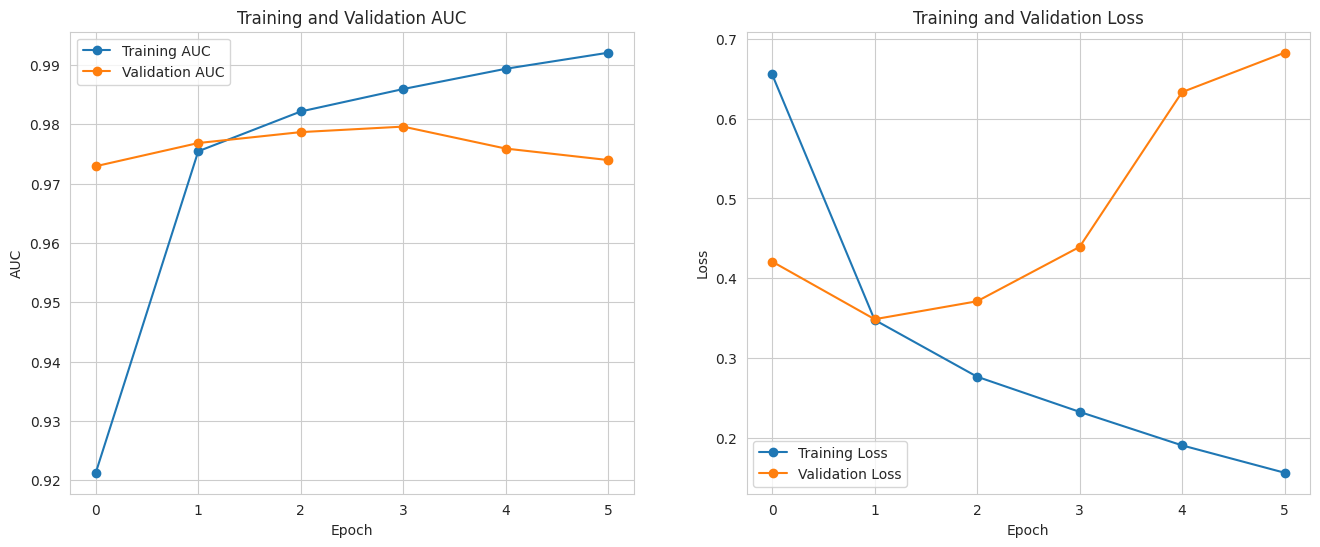

>>>>>>  Inizio ricerca soglia ottimale per ogni classe...
>>>>>> Soglia ottimale per 'toxic': 0.89 (con f1 di 0.7965)
>>>>>> Soglia ottimale per 'severe_toxic': 0.90 (con f1 di 0.4796)
>>>>>> Soglia ottimale per 'obscene': 0.90 (con f1 di 0.8006)
>>>>>> Soglia ottimale per 'threat': 0.90 (con f1 di 0.1916)
>>>>>> Soglia ottimale per 'insult': 0.90 (con f1 di 0.7358)
>>>>>> Soglia ottimale per 'identity_hate': 0.90 (con f1 di 0.3091)
>>>>>>valutazione finale su test set con soglie ottimizzate secondo f1
>>>> AUC score complessivo sul test set (metrica di riferimento): 0.9760


>>>>>Classification report sul test set (con soglie ottimizzate in base a f1-score):

               precision    recall  f1-score   support

        toxic       0.81      0.76      0.79      3056
 severe_toxic       0.32      0.85      0.47       321
      obscene       0.75      0.85      0.80      1715
       threat       0.09      0.61      0.16        74
       insult       0.64      0.77      0.70      1614


In [7]:
def plot_history_auc(history):
    plt.figure(figsize=(16, 6))
    #grafico AUC
    plt.subplot(1, 2, 1)
    plt.plot(history.history['auc'], label='Training AUC', marker='o')
    plt.plot(history.history['val_auc'], label='Validation AUC', marker='o')
    plt.title('Training and Validation AUC')
    plt.xlabel('Epoch'); plt.ylabel('AUC'); plt.legend()
    # grafico Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.show()

plot_history_auc(history)

#ottimizzazione della soglia basata su f1
print(">>>>>>  Inizio ricerca soglia ottimale per ogni classe...") #viene usata questa strategia perchè in altri test si è visto che una soglia unica non conduceva a risultati ottimali

y_val_pred_probs = model.predict(X_val, verbose=0)
optimal_thresholds = {}
for i, label in enumerate(label_cols):
    best_threshold = 0.5
    best_f1 = 0.0
    #iterazione su diverse soglie per trovare la migliore
    for threshold in np.arange(0.1, 0.91, 0.01):
        y_pred = (y_val_pred_probs[:, i] > threshold).astype(int)
        score = f1_score(y_val[:, i], y_pred)
        if score > best_f1:
            best_f1 = score
            best_threshold = threshold
    optimal_thresholds[label] = best_threshold
    print(f">>>>>> Soglia ottimale per '{label}': {best_threshold:.2f} (con f1 di {best_f1:.4f})")


#valutazione su test set
print(">>>>>>valutazione finale su test set con soglie ottimizzate secondo f1")

y_test_pred_probs = model.predict(X_test, verbose=0)
auc_test = roc_auc_score(y_test, y_test_pred_probs)
print(f">>>> AUC score complessivo sul test set (metrica di riferimento): {auc_test:.4f}\n")

y_test_pred_binary = np.zeros_like(y_test_pred_probs)
for i, label in enumerate(label_cols):
    y_test_pred_binary[:, i] = (y_test_pred_probs[:, i] > optimal_thresholds[label]).astype(int)

print("\n>>>>>Classification report sul test set (con soglie ottimizzate in base a f1-score):\n")
print(classification_report(y_test, y_test_pred_binary, target_names=label_cols, zero_division=0))


# Inferenza ed applicazione

In [8]:
def predict_toxicity(comment: str, thresholds: dict):
    sequence = tokenizer.texts_to_sequences([comment])
    padded_sequence = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')
    pred_probs = model.predict(padded_sequence, verbose=0)[0]
    results = {}
    print(f"Analisi del commento: \"{comment}\"\n")
    for i, label in enumerate(label_cols):
        is_present = bool(pred_probs[i] > thresholds[label])
        results[label] = {
            'presente': 'SÌ' if is_present else 'NO',
            'probabilità': f"{pred_probs[i]:.3f}",
            'soglia_usata': f"{thresholds[label]:.2f}"
        }
    return pd.DataFrame.from_dict(results, orient='index')

#esempi di applicazione
commento_offensivo = "you are a stupid idiot, go away from here"
commento_minaccioso = "I will find you and I will kill you for what you said"
commento_neutro = "I really like the new design of their website, it is very clean."

#la funzione di predizione userà le nuove soglie bilanciate
display(predict_toxicity(commento_offensivo, optimal_thresholds))
display(predict_toxicity(commento_minaccioso, optimal_thresholds))
display(predict_toxicity(commento_neutro, optimal_thresholds))

Analisi del commento: "you are a stupid idiot, go away from here"



,presente,probabilità,soglia_usata
toxic,SÌ,1.000,0.89
severe_toxic,SÌ,0.970,0.90
obscene,SÌ,0.998,0.90
threat,NO,0.853,0.90
insult,SÌ,0.993,0.90
identity_hate,SÌ,0.941,0.90


Analisi del commento: "I will find you and I will kill you for what you said"



,presente,probabilità,soglia_usata
toxic,SÌ,0.999,0.89
severe_toxic,SÌ,0.952,0.90
obscene,SÌ,0.929,0.90
threat,SÌ,0.995,0.90
insult,SÌ,0.987,0.90
identity_hate,SÌ,0.996,0.90


Analisi del commento: "I really like the new design of their website, it is very clean."



,presente,probabilità,soglia_usata
toxic,NO,0.023,0.89
severe_toxic,NO,0.000,0.90
obscene,NO,0.002,0.90
threat,NO,0.000,0.90
insult,NO,0.001,0.90
identity_hate,NO,0.000,0.90


**Commento risultati ottenuti** <br>
Il modello raggiunge un AUC complessivo sul test set di 0.9760, che indica un'eccellente capacità di distinguere tra commenti positivi e negativi in media su tutte le classi.

Il modello si comporta molto bene sulle categorie toxic, obscene, insult, con F1-score che va da 0.7 a 0.8. Questo significa che per le forme più comuni di tossicità, il modello è affidabile ed equilibrato tra precisione e recall.

D'altra parte, threat e identity_hate, soffrono di bassa precisione a causa della loro rarità. L'F1-score è basso (0.09 e 0.18).

**Analisi degli esempi**<br>
"you are a stupid idiot...": Classificato correttamente come toxic, obscene e insult. È interessante notare l'alta probabilità anche per severe_toxic e identity_hate, mostrando come il modello associ questo tipo di linguaggio a forme più gravi di tossicità.

"I will find you and I will kill you...": Classificato correttamente in tutte le categorie, inclusa threat con una probabilità altissima (0.995). Questo è un successo notevole e dimostra che il modello ha imparato a riconoscere le minacce esplicite.

"I really like the new design...": Classificato correttamente come non tossico in nessuna categoria, con probabilità vicine allo zero. Questo è fondamentale per garantire che il filtro non penalizzi le interazioni positive.